# VII Course on Machine Learning and Central Banking

## Causal Machine Learning & Explainable Machine Learning - Hands-On Exercises

## CEMLA and Deutsche Bundesbank, August 2026


**Example: Deposit outflows and recourse to the marginal lending facility**

A cross-section of banks in a **stressed quarter**. A deposit outflow opens a funding gap, and a bank closes it in order of preference: first the **interbank market**, and only when that is not enough, the central bank's **marginal lending facility**.

- What is the **causal effect** of deposit outflows on emergency central bank borrowing (marginal lending facility)?
- Is the effect **heterogeneous**? I.e., **for which banks**is the effect large?
- What do **explainability tools** tell us?

> **Estimand.** Effect of a **1 percentage-point increase in `deposit_outflow`** (% of deposits) **on `cb_borrowing`** (MLF recourse, % of assets) .

> We generate synthetic data, so we know the "true" causal effect). **True ATE ≈ 0.58**.



# Dependencies

In [67]:
# --- Import dependencies -------------------------------------------------------
%pip install econml dowhy PyALE effector

import numpy as np, pandas as pd, matplotlib.pyplot as plt, networkx as nx
import statsmodels.api as sm
import econml
import dowhy
from matplotlib.lines import Line2D
from scipy import stats
from sklearn.model_selection import KFold, train_test_split
from sklearn.inspection import permutation_importance, partial_dependence, PartialDependenceDisplay
from xgboost import XGBRegressor
from econml.dml import LinearDML, CausalForestDML
from econml.cate_interpreter import SingleTreeCateInterpreter, SingleTreePolicyInterpreter
from dowhy import CausalModel
from google.colab import data_table
data_table.enable_dataframe_formatter()

import warnings; warnings.filterwarnings("ignore")

SEED = 20260823
rng_global = np.random.default_rng(SEED)
pd.set_option("display.width", 160, "display.max_columns", 50)
plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
print("ok")

ok


# Data Overview

## Variable dictionary

| Variable | Role | Story |
|---|---|---|
| `deposit_outflow` | **treatment D** | deposits withdrawn over the stress quarter, % of deposits |
| `cb_borrowing` | **outcome Y** | recourse to the marginal lending facility, % of total assets |
| `cet1_ratio` | **confounder** | Common Equity Tier 1 capital ratio: the proxy for solvency risk: thin capital invites withdrawals *and* forces recourse |
| `collateral_ratio` | **effect modifier** | central-bank-eligible collateral as % of assets (capacity to draw on the facility) |
| `log_assets` | **effect modifier** | proxy for bank size - small banks have little market alternatives |
| `annual_report_pages` | **correlation trap** | numnber of pages in annual reports - 0.997 proxy for `log_assets`, but zero financial content |
| `interbank_borrowing` | **bad control (mediator)** | the first-choice liquidity source; substitutes for the MLF |
| `cds_spread` | **bad control (collider)** | the market's thermometer, priced off *both* `deposit_outflow` and `cb_borrowing`|

- We don't censor `cb_borrowing` to keep every estimator directly comparable
- Leaving `cet1_ratio` out biases the estimate **upward**, CET1 enters the outcome through a non-linear effect `exp(-0.30 · CET1)`
- **Conditioning on `interbank_borrowing`** closes the mediation/substitution channel and leaves only the direct effect of  `deposit_outflow` (the effect of an outflow among banks whose interbank position did not move - **not what we want**).
- CDS spread `cds_spread` as a market's publicly visible thermometer: low spread = the market thinks the bank is healthy. Dangerous because it **improves the fit** but adds **collider bias**
- The moderating effect of `collateral_ratio` enters as a **saturating curve** `1 - exp(-collateral/8)`, i.e. non-linear.
- `annual_report_pages`is a **dead end**: a child of `log_assets` with no path to the outcome (but it will draw "importance" in explainability

---

## The Directed Acyclic Graph (DAG)

We write the DAG as a `networkx` object, and reuse it for the picture, the `dowhy` causal model, and the identification step that decides which variables belong in the control set.

`collateral_ratio` and `log_assets` are *effect modifiers* and enter the outcome **only** through the interaction with the
treatment. However, in the notation here, arrows only point to nodes, so they point to `cb_borrowing`

8 nodes, 10 edges, acyclic: True
parents of the treatment: ['cet1_ratio']
parents of the outcome  : ['cet1_ratio', 'collateral_ratio', 'deposit_outflow', 'interbank_borrowing', 'log_assets']


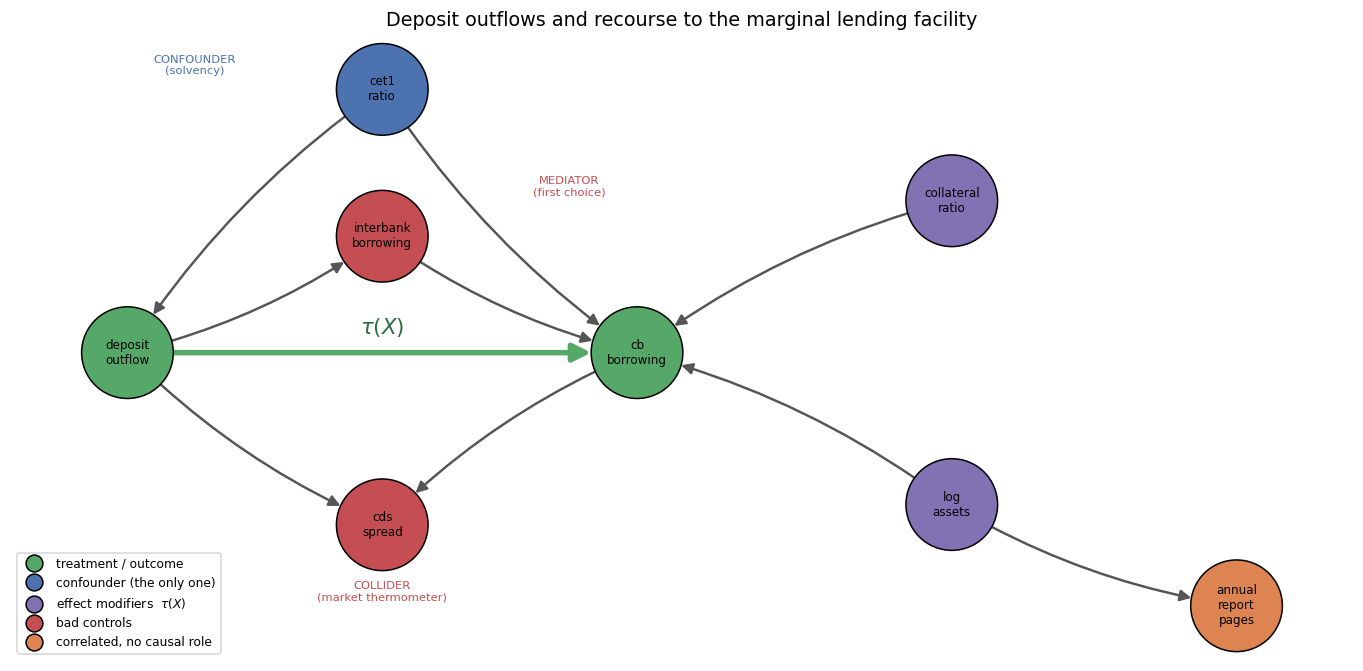

backdoor adjustment set : ['cet1_ratio']
effect modifiers        : ['collateral_ratio', 'log_assets']
interbank_borrowing    selected? False   <- MEDIATOR
cds_spread             selected? False   <- COLLIDER
annual_report_pages    selected? False   <- child of a modifier, dead end


In [25]:
# Drawing the DAG
EDGES = [
    # the effect we are after
    ("deposit_outflow", "cb_borrowing"),
    # cet1_ratio as a CONFOUNDER: solvency moves the treatment and the outcome
    ("cet1_ratio", "deposit_outflow"),
    ("cet1_ratio", "cb_borrowing"),
    # MODIFIERS: parents of the outcome, but not of the treatment
    ("collateral_ratio", "cb_borrowing"),
    ("log_assets", "cb_borrowing"),
    # MEDIATOR: outflows -> interbank market (first choice) -> less recourse to the MLF
    ("deposit_outflow", "interbank_borrowing"),
    ("interbank_borrowing", "cb_borrowing"),
    # COLLIDER: the market's thermometer, priced off the outflow and the stigma of the MLF
    ("deposit_outflow", "cds_spread"),
    ("cb_borrowing", "cds_spread"),
    # size proxy: bigger banks publish longer annual reports (but no structural effect)
    ("log_assets", "annual_report_pages"),
]

G = nx.DiGraph()
G.add_edges_from(EDGES)
gml = "".join(nx.generate_gml(G))          # the same graph, in the format dowhy reads

print(f"{G.number_of_nodes()} nodes, {G.number_of_edges()} edges, "
      f"acyclic: {nx.is_directed_acyclic_graph(G)}")
print("parents of the treatment:", sorted(G.predecessors("deposit_outflow")))
print("parents of the outcome  :", sorted(G.predecessors("cb_borrowing")))


POS = {"cet1_ratio": (1.7, 2.6), "interbank_borrowing": (1.7, 1.15),
       "deposit_outflow": (0, 0), "cb_borrowing": (3.4, 0), "cds_spread": (1.7, -1.7),
       "collateral_ratio": (5.5, 1.5), "log_assets": (5.5, -1.5),
       "annual_report_pages": (7.4, -2.5)}
NS = 3600

def draw_dag(colors, title, legend, ax=None):
    """Draw the DAG with a caller-supplied node colouring. All edges identical."""
    ax = ax or plt.gca()
    effect = [("deposit_outflow", "cb_borrowing")]
    others = [e for e in G.edges if e not in effect]
    nx.draw_networkx_nodes(G, POS, ax=ax, node_size=NS, edgecolors="black",
                           node_color=[colors[v] for v in G])
    nx.draw_networkx_edges(G, POS, edgelist=others, ax=ax, node_size=NS,
                           arrowsize=15, width=1.6, edge_color="#555555",
                           connectionstyle="arc3,rad=0.10")
    nx.draw_networkx_edges(G, POS, edgelist=effect, ax=ax, node_size=NS,
                           arrowsize=24, width=3.6, edge_color="#55A868")
    nx.draw_networkx_labels(G, POS, ax=ax, font_size=7.8,
                            labels={v: v.replace("_", "\n") for v in G})
    ax.annotate(r"$\tau(X)$", xy=(1.7, 0.18), fontsize=14, color="#2E6B45", ha="center")
    ax.set_axis_off(); ax.set_title(title, fontsize=12.5)
    ax.legend(handles=legend, loc="lower left", fontsize=8)

GREEN, BLUE, PURPLE, RED, ORANGE, GREY = "#55A868", "#4C72B0", "#8172B3", "#C44E52", "#DD8452", "#BBBBBB"
declared = {"deposit_outflow": GREEN, "cb_borrowing": GREEN, "cet1_ratio": BLUE,
            "collateral_ratio": PURPLE, "log_assets": PURPLE,
            "interbank_borrowing": RED, "cds_spread": RED, "annual_report_pages": ORANGE}
dot = lambda c, l: Line2D([], [], marker="o", ls="", ms=11, mfc=c, mec="k", label=l)

fig, ax = plt.subplots(figsize=(12.5, 6.2))
draw_dag(declared, "Deposit outflows and recourse to the marginal lending facility",
         [dot(GREEN, "treatment / outcome"), dot(BLUE, "confounder (the only one)"),
          dot(PURPLE, r"effect modifiers  $\tau(X)$"), dot(RED, "bad controls"),
          dot(ORANGE, "correlated, no causal role")], ax)
for xy, txt, col in [((0.45, 2.75), "CONFOUNDER\n(solvency)", BLUE),
                     ((2.95, 1.55), "MEDIATOR\n(first choice)", RED),
                     ((1.7, -2.45), "COLLIDER\n(market thermometer)", RED)]:
    ax.annotate(txt, xy=xy, fontsize=7.5, color=col, ha="center")
plt.tight_layout(); plt.show()

# Roles read straight off the graph
T, O = "deposit_outflow", "cb_borrowing"

# Adjusting for the parents of the treatment
backdoor = sorted(G.predecessors(T))

# Effect modifiers: parents of the outcome that are neither the treatment, nor downstream of it
downstream = nx.descendants(G, T) | {T}
modifiers  = sorted(set(G.predecessors(O)) - downstream - set(backdoor))

print("backdoor adjustment set :", backdoor)     # ['cet1_ratio']
print("effect modifiers        :", modifiers)    # ['collateral_ratio', 'log_assets']

for bad, why in [("interbank_borrowing", "MEDIATOR"),
                 ("cds_spread", "COLLIDER"),
                 ("annual_report_pages", "child of a modifier, dead end")]:
    print(f"{bad:22s} selected? {bad in backdoor or bad in modifiers}   <- {why}")

## Generate the Data

In [10]:
# Structural parameters
BETA_M   = -0.45     # dY/dM : interbank funding substitutes for the emergency facility
GAMMA_MD =  0.35     # dM/dD : share of an outflow refinanced in the interbank market

def tau_direct_of(collateral_ratio, log_assets):
    """DIRECT effect of +1pp deposit outflow, holding interbank borrowing fixed.

    Two modifiers, one saturating and one linear:
      * collateral: you can only pledge what you hold, and past ~20% it stops binding
      * size:       large banks have market alternatives
    """
    return (1.00 - 0.12*(log_assets - 10.5)) * (1 - np.exp(-collateral_ratio/8.0))

def tau_total_of(collateral_ratio, log_assets):
    """TOTAL effect = direct + indirect through the mediator.  <-- this is our estimand."""
    return tau_direct_of(collateral_ratio, log_assets) + BETA_M*GAMMA_MD


def simulate_banks(n=5_000, seed=SEED):
    """Cross-section of `n` banks in a stressed quarter. Returns a DataFrame incl. ground truth."""
    rng = np.random.default_rng(seed)

    # Independent bank characteristics
    log_assets       = rng.normal(10.5, 1.5, n)                    # MODIFIER - proxy for bank size (EUR m)
    cet1_ratio       = np.clip(rng.normal(14.5, 2.8, n), 8, 26)    # CONFOUNDER
    collateral_ratio = np.clip(rng.normal(12.0, 4.5, n), 2, 30)    # MODIFIER

    # Trap for explainability: bigger banks publish longer annual reports
    annual_report_pages = np.clip(np.round(np.exp(4.6 + 0.30*(log_assets - 10.5)
                                                  + rng.normal(0, 0.035, n))), 40, None)

    # TREATMENT: deposit outflow (% of deposits)
    deposit_outflow = np.clip(15.0 - 0.45*cet1_ratio
                              + 0.035*(cet1_ratio - 14.5)**2          # non-linear in capital
                              + rng.normal(0, 1.6, n), 0, None)

    # MEDIATOR: interbank borrowing, the first choice for liquidity
    interbank_borrowing = 3.0 + GAMMA_MD*deposit_outflow + rng.normal(0, 0.8, n)

    # OUTCOME: recourse to the marginal lending facility (% of assets)
    tau_direct = tau_direct_of(collateral_ratio, log_assets)
    g = 12.5 - 0.60*cet1_ratio + 7.0*np.exp(-0.30*(cet1_ratio - 8))   # solvency, non-linear
    cb_borrowing = (g + tau_direct*deposit_outflow
                    + BETA_M*interbank_borrowing + rng.normal(0, 0.8, n))

    # COLLIDER: cds spread, descendant of the outflow and the cb borrowing --
    cds_spread = 70 + 5.0*deposit_outflow + 9.0*cb_borrowing + rng.normal(0, 15, n)

    return pd.DataFrame(dict(
        deposit_outflow=deposit_outflow, cb_borrowing=cb_borrowing,
        cet1_ratio=cet1_ratio, collateral_ratio=collateral_ratio, log_assets=log_assets,
        annual_report_pages=annual_report_pages,
        interbank_borrowing=interbank_borrowing, cds_spread=cds_spread,
        tau_true=tau_direct + BETA_M*GAMMA_MD))


df = simulate_banks()
print(df.shape)
df.head()

# Further inspect the data set
# display(df)

(5000, 9)


,deposit_outflow,cb_borrowing,cet1_ratio,collateral_ratio,log_assets,annual_report_pages,interbank_borrowing,cds_spread,tau_true
0,8.613718,12.284483,11.861396,8.526987,9.635612,76.0,6.911061,235.081081,0.566073
1,8.618026,7.743836,15.757209,13.889398,11.137022,115.0,5.648322,193.058705,0.603333
2,8.032481,9.915531,12.918751,18.355964,11.692870,148.0,5.401622,185.850273,0.612974
3,8.349022,6.519449,16.609975,11.066711,8.789201,60.0,7.250404,144.324404,0.745580
4,10.282402,13.808705,14.641896,18.169546,8.205783,53.0,7.364528,236.058736,0.986208


## Inspect the Ground Truth

TRUE ATE     : 0.5780
TRUE CATE sd : 0.1997   range [-0.01, 1.38]


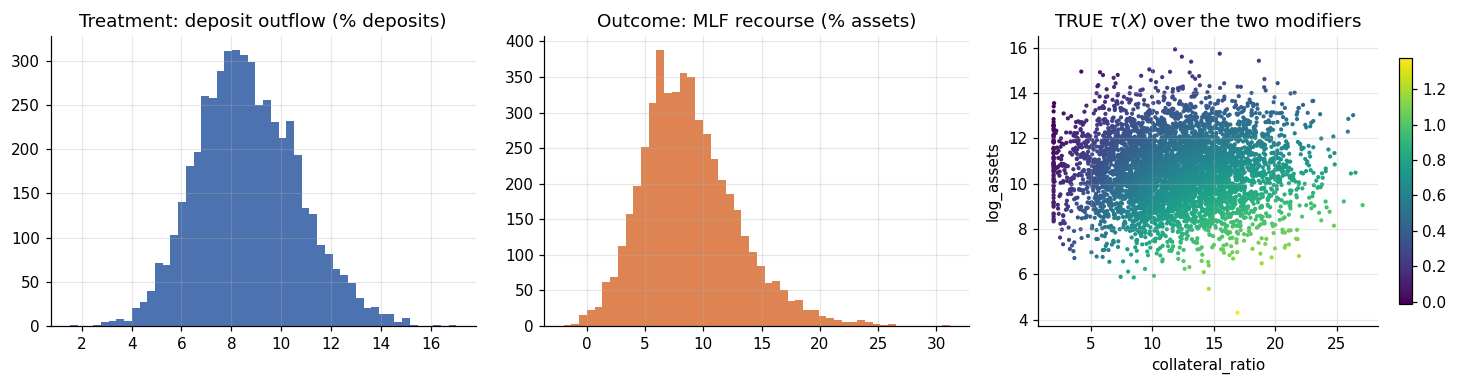

In [26]:
# Ground truth
TRUE_ATE = df.tau_true.mean()
print(f"TRUE ATE     : {TRUE_ATE:.4f}")
print(f"TRUE CATE sd : {df.tau_true.std():.4f}   range "
      f"[{df.tau_true.min():.2f}, {df.tau_true.max():.2f}]")

fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.6))
ax[0].hist(df.deposit_outflow, bins=50, color="#4C72B0")
ax[0].set_title("Treatment: deposit outflow (% deposits)")
ax[1].hist(df.cb_borrowing, bins=50, color="#DD8452")
ax[1].set_title("Outcome: MLF recourse (% assets)")
sc = ax[2].scatter(df.collateral_ratio, df.log_assets, c=df.tau_true, s=3, cmap="viridis")
ax[2].set_xlabel("collateral_ratio"); ax[2].set_ylabel("log_assets")
ax[2].set_title(r"TRUE $\tau(X)$ over the two modifiers")
fig.colorbar(sc, ax=ax[2], shrink=.85)
plt.tight_layout(); plt.show()

## The non-linear heterogeneity ML should recover

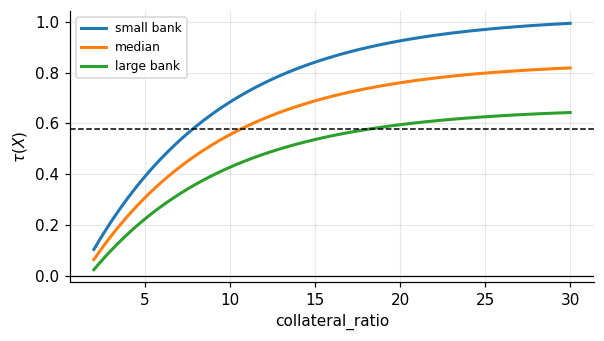

In [18]:
# The non-linear heterogeneity ML should recover

grid = np.linspace(2, 30, 100)
fig, ax = plt.subplots(figsize=(5.6, 3.2))
for s_, lab in [(9.0, "small bank"), (10.5, "median"), (12.0, "large bank")]:
    ax.plot(grid, tau_total_of(grid, s_), lw=2, label=lab)
ax.axhline(0, color="k", lw=.8)
ax.axhline(TRUE_ATE, color="k", ls="--", lw=1)
ax.set_xlabel("collateral_ratio"); ax.set_ylabel(r"$\tau(X)$")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

# Day 1: Causal Machine Learning

## Helper functions

In [31]:
def stars(p):
    return "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.1 else ""

def ols(y, X):
    return sm.OLS(y, sm.add_constant(X, has_constant="add")).fit()

def reg_table(models, order, labels=None, dec=3, note=None, title=""):
    labels = labels or {}
    cols, rows = list(models), []
    rows.append([""] + [f"({i+1})" for i in range(len(cols))])
    for v in order:
        c, s = [], []
        for m in cols:
            r = models[m]
            if v in r.params.index:
                c.append(f"{r.params[v]:,.{dec}f}{stars(r.pvalues[v])}")
                s.append(f"({r.bse[v]:,.{dec}f})")
            else:
                c.append(""); s.append("")
        if any(c):                                   # skip rows no model has
            rows.append([labels.get(v, v)] + c)
            rows.append([""] + s)
    n_coef = len(rows)
    add = lambda nm, fn: rows.append([nm] + [fn(models[m]) for m in cols])
    add("Observations",        lambda r: f"{int(r.nobs):,}")
    add("R2",                  lambda r: f"{r.rsquared:.3f}")
    add("Adjusted R2",         lambda r: f"{r.rsquared_adj:.3f}")
    add("Residual Std. Error", lambda r: f"{np.sqrt(r.mse_resid):,.3f} (df = {int(r.df_resid):,})")
    add("F Statistic",         lambda r: f"{r.fvalue:,.3f}{stars(r.f_pvalue)} "
                                         f"(df = {int(r.df_model)}; {int(r.df_resid):,})")
    rows.append(["Note:"] + [""]*(len(cols)-1) + [note or "*p<0.1; **p<0.05; ***p<0.01"])
    out = pd.DataFrame(rows, columns=[title] + cols)
    out.attrs.update(head_rule=1, stat_rule=n_coef, note_rule=len(rows)-1)
    return out

def show(tbl):
    hr, sr, nr = tbl.attrs["head_rule"], tbl.attrs["stat_rule"], tbl.attrs["note_rule"]
    def borders(d):
        css = pd.DataFrame("", index=d.index, columns=d.columns)
        css.iloc[hr-1, :] = "border-bottom: 1px solid #444;"
        css.iloc[sr-1, :] = "border-bottom: 1px solid #444;"
        css.iloc[nr-1, :] = "border-bottom: 1px solid #444;"
        css.iloc[nr, :]   = "border: none; font-style: italic; color: #444;"
        return css
    return (tbl.style.hide(axis="index").apply(borders, axis=None)
              .set_properties(**{"text-align": "right", "font-size": "12px",
                                 "padding": "2px 10px", "white-space": "nowrap"})
              .set_properties(subset=[tbl.columns[0]], **{"text-align": "left"})
              .set_table_styles([
                  {"selector": "", "props": "border-top: 2px solid #222; border-collapse: collapse;"},
                  {"selector": "thead th", "props": "border-bottom: 1px solid #444; text-align: right;"
                                                    " font-weight: 600; padding: 3px 10px;"},
                  {"selector": "thead th:first-child", "props": "text-align: left; font-weight: 700;"},
              ]))


## OLS with Different Sets of Controls

In [33]:
BACKDOOR = list(backdoor)                                # what dowhy said we NEED: {cet1_ratio}
HET_X    = list(modifiers)                               # what dowhy called effect modifiers
GOOD_W   = BACKDOOR + HET_X + ["annual_report_pages"]    # everything legitimately observable
MEDIATOR = "interbank_borrowing"
COLLIDER = "cds_spread"

D, Y = "deposit_outflow", "cb_borrowing"
y = df[Y]

m_naive    = ols(y, df[[D]]) # regression only with the treatment ()
m_multiple = ols(y, df[[D] + GOOD_W])
m_mediator = ols(y, df[[D] + GOOD_W + [MEDIATOR]])
m_collider = ols(y, df[[D] + GOOD_W + [COLLIDER]])

for name, m in [("Naive OLS", m_naive), ("Multiple OLS", m_multiple),
                ("OLS + mediator", m_mediator), ("OLS + collider", m_collider)]:
    b, se = m.params[D], m.bse[D]
    print(f"{name:16s} {b:6.3f}  ({se:.3f})   bias vs truth {b-TRUE_ATE:+.3f}"
          f"  ({100*(b-TRUE_ATE)/TRUE_ATE:+.0f}%)")
print(f"{'TRUTH':16s} {TRUE_ATE:6.3f}")


Naive OLS         1.406  (0.021)   bias vs truth +0.828  (+143%)
Multiple OLS      0.652  (0.010)   bias vs truth +0.074  (+13%)
OLS + mediator    0.799  (0.012)   bias vs truth +0.221  (+38%)
OLS + collider    0.230  (0.012)   bias vs truth -0.348  (-60%)
TRUTH             0.578


In [34]:
ROW_ORDER = [D, "D_tilde", "cet1_ratio", "collateral_ratio", "log_assets",
             "annual_report_pages", MEDIATOR, COLLIDER, "const"]
ROW_LABELS = {D: "Treatment: Deposit outflows",
              "D_tilde": "Residualised Treatment: Deposit outflows",
              "cet1_ratio": "CET1 capital ratio",
              "collateral_ratio": "Collateral ratio",
              "log_assets": "Bank size (log assets)",
              "annual_report_pages": "Annual report (pages)",
              MEDIATOR: "Interbank borrowing  [MEDIATOR]",
              COLLIDER: "CDS spread  [COLLIDER]",
              "const": "Intercept"}

tbl = reg_table({"Naive OLS": m_naive, "Multiple OLS": m_multiple,
                 "OLS w/ Mediator": m_mediator, "OLS w/ Collider": m_collider},
                order=ROW_ORDER, labels=ROW_LABELS,
                title="Example 1: Obtaining Exogeneity w/ DML",
                note=f"TRUE ATE = {TRUE_ATE:.3f}.  *p<0.1; **p<0.05; ***p<0.01")
display(show(tbl))

Example 1: Obtaining Exogeneity w/ DML,Naive OLS,Multiple OLS,OLS w/ Mediator,OLS w/ Collider
,(1),(2),(3),(4)
Treatment: Deposit outflows,1.406***,0.652***,0.799***,0.230***
,(0.021),(0.010),(0.012),(0.012)
CET1 capital ratio,,-0.956***,-0.955***,-0.618***
,,(0.008),(0.007),(0.009)
Collateral ratio,,0.270***,0.270***,0.175***
,,(0.004),(0.004),(0.004)
Bank size (log assets),,-0.765***,-0.770***,-0.487***
,,(0.035),(0.033),(0.029)
Annual report (pages),,-0.000,-0.000,-0.001


- **Naive OLS** returns roughly **two and a half times** the truth. One omitted confounder is enough.

- **Multiple OLS** with **good controls** does much better. But the **functional form is wrong** ( non-linear `exp(-CET1)`, and an effect that varies across banks).

- **+ mediator** wrongly conditions away the interbank substitution channel, and the **bias** goes back up

- **+ collider** conditioning on the CDS spread **biases** the model and cuts the estimate by more than half. Worringly: its **R² is the highest** of the four models.

## Double Machine Learning "By Hand" with XGBoost

Partially linear model: $Y = \tau D + g(W) + \varepsilon,\qquad D = m(W) + \nu$

1. Predict $Y$ from $W$ with any ML learner → residual $\tilde Y = Y - \hat g(W)$
2. Predict $D$ from $W$ with any ML learner → residual $\tilde D = D - \hat m(W)$
3. Regress $\tilde Y$ on $\tilde D$ → $\hat\tau$   *(Frisch–Waugh–Lovell with ML in the first stage)*

**Cross-fitting** (each residual predicted by a model that never saw that observation) is what removes the
regularisation bias. Let's do it by hand first, then call `econml`.

### Helper functions

In [40]:
# Helper functions

def xgb(seed=0, **kw):
    p = dict(n_estimators=400, max_depth=4, learning_rate=0.06, subsample=0.8,
             colsample_bytree=0.8, reg_lambda=1.0, min_child_weight=10,
             n_jobs=-1, random_state=seed, verbosity=0)
    p.update(kw)
    return XGBRegressor(**p)

def crossfit_residuals(data, outcome, treatment, controls, n_folds=5, seed=SEED):
    """Cross-fitted residuals for Y and D. Returns (Y_tilde, D_tilde, R2_y, R2_d)."""
    W = data[controls].to_numpy(float)
    yv, dv = data[outcome].to_numpy(float), data[treatment].to_numpy(float)
    y_hat, d_hat = np.zeros_like(yv), np.zeros_like(dv)
    for tr, te in KFold(n_folds, shuffle=True, random_state=seed).split(W):
        y_hat[te] = xgb(seed).fit(W[tr], yv[tr]).predict(W[te])
        d_hat[te] = xgb(seed).fit(W[tr], dv[tr]).predict(W[te])
    r2 = lambda a, b: 1 - ((a-b)**2).sum() / ((a-a.mean())**2).sum()
    return yv - y_hat, dv - d_hat, r2(yv, y_hat), r2(dv, d_hat)

### Using good controls

In [39]:
y_t, d_t, r2y, r2d = crossfit_residuals(df, Y, D, GOOD_W) # using good controls!
print(f"first-stage out-of-fold R2:   E[Y|W] = {r2y:.3f}    E[D|W] = {r2d:.3f}")

res_df = pd.DataFrame({"Y_tilde": y_t, "D_tilde": d_t})
m_dml  = ols(res_df.Y_tilde, res_df[["D_tilde"]])
print(f"\nDML (manual)  tau = {m_dml.params['D_tilde']:.4f}  ({m_dml.bse['D_tilde']:.4f})"
      f"   truth = {TRUE_ATE:.4f}")

first-stage out-of-fold R2:   E[Y|W] = 0.889    E[D|W] = 0.327

DML (manual)  tau = 0.5755  (0.0083)   truth = 0.5780


### Using bad controls

In [41]:
# Now we throw in a bad control thrown into the conditioning set
y_tb, d_tb, _, _ = crossfit_residuals(df, Y, D, GOOD_W + [COLLIDER])
m_dml_collider = ols(pd.Series(y_tb, name="Y_tilde"), pd.DataFrame({"D_tilde": d_tb}))

y_tm, d_tm, _, _ = crossfit_residuals(df, Y, D, GOOD_W + [MEDIATOR])
m_dml_mediator = ols(pd.Series(y_tm, name="Y_tilde"), pd.DataFrame({"D_tilde": d_tm}))

# Only with the minimal backdoor control set
y_t0, d_t0, _, _ = crossfit_residuals(df, Y, D, BACKDOOR)
m_dml_minimal = ols(pd.Series(y_t0, name="Y_tilde"), pd.DataFrame({"D_tilde": d_t0}))

print(f"DML, full control set   {m_dml.params['D_tilde']:.4f}  (se {m_dml.bse['D_tilde']:.4f})")
print(f"DML, minimal backdoor   {m_dml_minimal.params['D_tilde']:.4f}  (se {m_dml_minimal.bse['D_tilde']:.4f})")
print(f"DML + collider          {m_dml_collider.params['D_tilde']:.4f}")
print(f"DML + mediator          {m_dml_mediator.params['D_tilde']:.4f}")
print(f"TRUTH                   {TRUE_ATE:.4f}")

DML, full control set   0.5755  (se 0.0083)
DML, minimal backdoor   0.5951  (se 0.0173)
DML + collider          0.3065
DML + mediator          0.7207
TRUTH                   0.5780


## Table Comparison of Different Models and Recovered Treatment Effects

In [45]:
def show(tbl):
    """Stargazer-style rendering. Borders applied LAST so they win the CSS cascade."""
    hr, sr, nr = tbl.attrs["head_rule"], tbl.attrs["stat_rule"], tbl.attrs["note_rule"]
    def rules(d):
        css = pd.DataFrame("", index=d.index, columns=d.columns)
        css.iloc[hr-1, :] = "border-bottom: 1px solid #444;"
        css.iloc[sr-1, :] = "border-bottom: 1px solid #444;"
        css.iloc[nr-1, :] = "border-bottom: 1px solid #444;"
        css.iloc[nr, :]   = ("border: none; font-style: italic; color: #444;"
                             " white-space: normal; font-size: 11px;")
        return css
    return (tbl.style.hide(axis="index")
              .set_properties(**{"text-align": "right", "font-size": "12px",
                                 "padding": "2px 10px", "white-space": "nowrap"})
              .set_properties(subset=[tbl.columns[0]], **{"text-align": "left"})
              .apply(rules, axis=None)
              .set_table_styles([
                  {"selector": "", "props": "border-top: 2px solid #222; border-collapse: collapse;"},
                  {"selector": "thead th", "props": "border-bottom: 1px solid #444; text-align: right;"
                                                    " font-weight: 600; padding: 3px 10px;"},
                  {"selector": "thead th:first-child", "props": "text-align: left; font-weight: 700;"},
              ]))

# Comparison Table
ROW_ORDER = [D, "D_tilde", "cet1_ratio", "collateral_ratio", "log_assets",
             "annual_report_pages", MEDIATOR, COLLIDER, "const"]
ROW_LABELS = {D: "Treatment: Deposit outflows",
              "D_tilde": "Residualised Treatment: Deposit outflows",
              "cet1_ratio": "CET1 capital ratio  [CONFOUNDER]",
              "collateral_ratio": "Collateral ratio",
              "log_assets": "Bank size (log assets)",
              "annual_report_pages": "Annual report (pages)",
              MEDIATOR: "Interbank borrowing  [MEDIATOR]",
              COLLIDER: "CDS spread  [COLLIDER]",
              "const": "Intercept"}

tbl = reg_table(
    {"Naive OLS": m_naive, "Multiple OLS": m_multiple, "OLS w/ Mediator": m_mediator,
     "OLS w/ Collider": m_collider, "DML": m_dml,
     "DML w/ Mediator": m_dml_mediator, "DML w/ Collider": m_dml_collider},
    order=ROW_ORDER, labels=ROW_LABELS,
    title="Table 1: Effect of deposit outflows on recourse to the marginal lending facility",
    note=(f"TRUE ATE = {TRUE_ATE:.3f}. Columns (5)-(7) regress the cross-fitted DML residual of "
          "the outcome on the residualised treatment (XGBoost first stage, 5 folds); columns (6) "
          "and (7) put a bad control in the conditioning set. "
          "*p<0.1; **p<0.05; ***p<0.01"))

display(show(tbl))

Table 1: Effect of deposit outflows on recourse to the marginal lending facility,Naive OLS,Multiple OLS,OLS w/ Mediator,OLS w/ Collider,DML,DML w/ Mediator,DML w/ Collider
,(1),(2),(3),(4),(5),(6),(7)
Treatment: Deposit outflows,1.406***,0.652***,0.799***,0.230***,,,
,(0.021),(0.010),(0.012),(0.012),,,
Residualised Treatment: Deposit outflows,,,,,0.576***,0.721***,0.306***
,,,,,(0.008),(0.009),(0.010)
CET1 capital ratio [CONFOUNDER],,-0.956***,-0.955***,-0.618***,,,
,,(0.008),(0.007),(0.009),,,
Collateral ratio,,0.270***,0.270***,0.175***,,,
,,(0.004),(0.004),(0.004),,,
Bank size (log assets),,-0.765***,-0.770***,-0.487***,,,


## Chart Comparison of Different Models and Recovered Treatment Effects

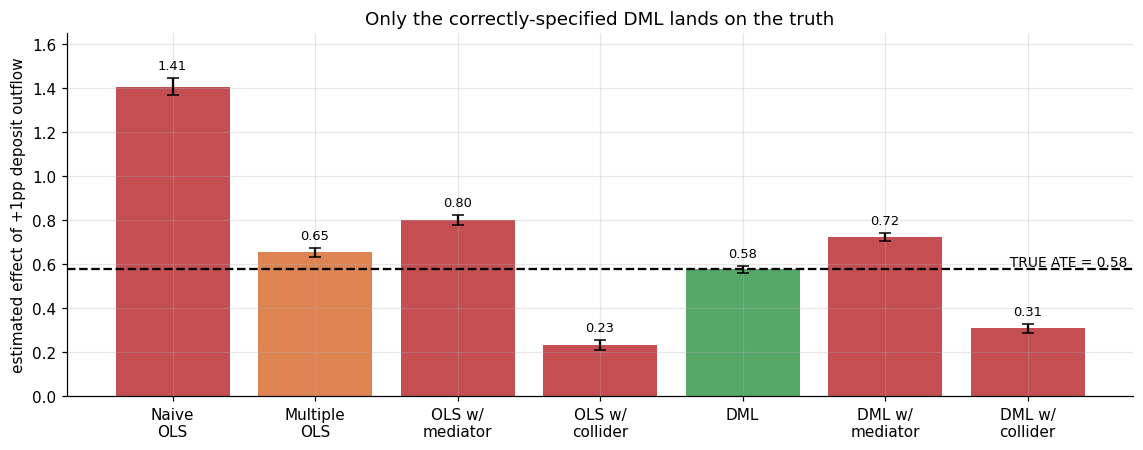

In [46]:
BARS = [
    ("Naive\nOLS",        m_naive,         D,         "#C44E52"),
    ("Multiple\nOLS",     m_multiple,      D,         "#DD8452"),
    ("OLS w/\nmediator",  m_mediator,      D,         "#C44E52"),
    ("OLS w/\ncollider",  m_collider,      D,         "#C44E52"),
    ("DML",               m_dml,           "D_tilde", "#55A868"),
    ("DML w/\nmediator",  m_dml_mediator,  "D_tilde", "#C44E52"),
    ("DML w/\ncollider",  m_dml_collider,  "D_tilde", "#C44E52"),
]
labels = [b[0] for b in BARS]
vals   = np.array([b[1].params[b[2]] for b in BARS])
ses    = np.array([b[1].bse[b[2]]    for b in BARS])
colors = [b[3] for b in BARS]

fig, ax = plt.subplots(figsize=(10.5, 4.2))
ax.bar(labels, vals, yerr=1.96*ses, color=colors, capsize=4)
ax.axhline(TRUE_ATE, color="k", ls="--", lw=1.5)
ax.text(0.995, TRUE_ATE, f"  TRUE ATE = {TRUE_ATE:.2f}",
        transform=ax.get_yaxis_transform(), ha="right", va="bottom", fontsize=9)
for i, (v, s) in enumerate(zip(vals, ses)):
    ax.text(i, v + 1.96*s + 0.02*max(vals), f"{v:.2f}", ha="center", va="bottom", fontsize=8.5)
ax.set_ylabel("estimated effect of +1pp deposit outflow")
ax.set_title("Only the correctly-specified DML lands on the truth")
ax.margins(y=0.14)
plt.tight_layout(); plt.show()

## Using econML (LinearDML) for the Average Treatment Effect (ATE)

In [47]:
W_good = df[GOOD_W].to_numpy(float)
Yv, Dv = df[Y].to_numpy(float), df[D].to_numpy(float)

dml = LinearDML(model_y=xgb(1), model_t=xgb(1),
                discrete_treatment=False, cv=5, random_state=SEED)
dml.fit(Yv, Dv, X=None, W=W_good)        # X=None -> constant treatment effect

def econml_ate(est, X=None):
    """Point estimate and standard error of the ATE from any econml estimator."""
    inf = est.ate_inference(X=X) if X is not None else est.ate_inference()
    return float(np.squeeze(inf.mean_point)), float(np.squeeze(inf.stderr_mean))

ate, se = econml_ate(dml)
print(f"LinearDML  ATE = {ate:.4f}  (se {se:.4f})   TRUTH = {TRUE_ATE:.4f}\n")
print(dml.summary(treatment_names=["deposit_outflow"]))

LinearDML  ATE = 0.5765  (se 0.0092)   TRUTH = 0.5780

Coefficient Results:  X is None, please call intercept_inference to learn the constant!
                       CATE Intercept Results                       
               point_estimate stderr zstat  pvalue ci_lower ci_upper
--------------------------------------------------------------------
cate_intercept          0.577  0.009 62.422    0.0    0.558    0.595
--------------------------------------------------------------------

<sub>A linear parametric conditional average treatment effect (CATE) model was fitted:
$Y = \Theta(X)\cdot T + g(X, W) + \epsilon$
where for every outcome $i$ and treatment $j$ the CATE $\Theta_{ij}(X)$ has the form:
$\Theta_{ij}(X) = X' coef_{ij} + cate\_intercept_{ij}$
Coefficient Results table portrays the $coef_{ij}$ parameter vector for each outcome $i$ and treatment $j$. Intercept Results table portrays the $cate\_intercept_{ij}$ parameter.</sub>


In [48]:
# ---- looking at the estimate through econml's inference objects ----------
inf = dml.effect_inference()

print(">>> population_summary(): what goes in the footnote")
print(inf.population_summary())

print("\n>>> summary_frame(): the same thing as a tidy table")
print("    (one row -- with X=None the effect is a single constant)")
display(inf.summary_frame(alpha=0.05).round(4))

>>> population_summary(): what goes in the footnote
               Uncertainty of Mean Point Estimate               
mean_point stderr_mean zstat  pvalue ci_mean_lower ci_mean_upper
----------------------------------------------------------------
     0.577       0.009 62.422    0.0         0.558         0.595
      Distribution of Point Estimate     
std_point pct_point_lower pct_point_upper
-----------------------------------------
      0.0           0.577           0.577
     Total Variance of Point Estimate     
stderr_point ci_point_lower ci_point_upper
------------------------------------------
       0.009          0.558          0.595
------------------------------------------

>>> summary_frame(): the same thing as a tidy table
    (one row -- with X=None the effect is a single constant)


,point_estimate,stderr,zstat,pvalue,ci_lower,ci_upper
X,,,,,,
0,0.577,0.009,62.422,0.0,0.558,0.595


## Modeling Heterogeneity with CausalForestDML in the Last Step

- The **ATE of 0.58** hides the **heterogeneity** (`log_assets` and `collateral_ratio` are the **effect modifiers**).
The true effect runs from roughly **0.9 for a small,
well-collateralised bank** down to **near 0 for a large bank with no collateral to pledge**.

`CausalForestDML` = the same residualisation as before, but the final stage is a **causal forest** that splits on
`X` to estimate $\tau(X)$ locally, with honest sample splitting and valid confidence intervals. `X` enters
twice: as a control (like everything in `W`) and as a splitting variable for the effect.


In [50]:
REST_W = [c for c in GOOD_W if c not in HET_X]      # controls that are NOT modifiers

Xhet  = df[HET_X].to_numpy(float)
Wrest = df[REST_W].to_numpy(float)
print("X (heterogeneity):", HET_X, "   W (nuisance only):", REST_W)

cf = CausalForestDML(model_y=xgb(2), model_t=xgb(2),
                     discrete_treatment=False,
                     n_estimators=1000, min_samples_leaf=25,
                     max_samples=0.45, honest=True,
                     cv=5, random_state=SEED, n_jobs=-1)
cf.fit(Yv, Dv, X=Xhet, W=Wrest)

cate   = cf.effect(Xhet)
lo, hi = cf.effect_interval(Xhet, alpha=0.05)
df["cate_hat"] = cate

ate_cf, se_cf = econml_ate(cf, Xhet)
print(f"\nCausal forest ATE = {ate_cf:.4f} (se {se_cf:.4f})   TRUTH = {TRUE_ATE:.4f}")
print(f"CATE sd: estimated {cate.std():.3f}   true {df.tau_true.std():.3f}")
print(f"corr with true tau:  causal forest {np.corrcoef(cate, df.tau_true)[0,1]:.3f}"
      f"   |   LinearDML {np.corrcoef(cate_lin, df.tau_true)[0,1]:.3f}")

X (heterogeneity): ['collateral_ratio', 'log_assets']    W (nuisance only): ['cet1_ratio', 'annual_report_pages']

Causal forest ATE = 0.5831 (se 0.0371)   TRUTH = 0.5780
CATE sd: estimated 0.188   true 0.200
corr with true tau:  causal forest 0.975   |   LinearDML 0.958


## Check the Results

In [51]:
# Population summary --------------------------------------
# effect_inference() carries point estimates, standard errors and intervals for every observation
# population_summary() collapses them
print(cf.effect_inference(Xhet).population_summary())

               Uncertainty of Mean Point Estimate               
mean_point stderr_mean zstat  pvalue ci_mean_lower ci_mean_upper
----------------------------------------------------------------
     0.583       0.037 15.728    0.0          0.51         0.656
      Distribution of Point Estimate     
std_point pct_point_lower pct_point_upper
-----------------------------------------
    0.188           0.208           0.935
     Total Variance of Point Estimate     
stderr_point ci_point_lower ci_point_upper
------------------------------------------
       0.191          0.204          0.944
------------------------------------------

Note: The stderr_mean is a conservative upper bound.


## Create post-hoc Groups for Interpretation

In [52]:
# Name post-hoc groups to inspect heterogeneity, generate confidence intervals
profiles = pd.DataFrame(
    [[20.0,  9.0],
     [12.0, 10.5],
     [18.0, 12.0],
     [ 4.0,  9.5]],
    columns=HET_X,
    index=["small, well-collateralised", "median bank",
           "large, well-collateralised", "small, collateral-poor"])

prof_tbl = cf.effect_inference(profiles.to_numpy(float)).summary_frame(alpha=0.05).round(3)
prof_tbl.index = profiles.index
prof_tbl["TRUE tau"] = np.round(tau_total_of(profiles.collateral_ratio.to_numpy(),
                                             profiles.log_assets.to_numpy()), 3)
display(pd.concat([profiles, prof_tbl], axis=1))

,collateral_ratio,log_assets,point_estimate,stderr,zstat,pvalue,ci_lower,ci_upper,TRUE tau
"small, well-collateralised",20.0,9.0,0.892,0.048,18.429,0.0,0.797,0.987,0.926
median bank,12.0,10.5,0.683,0.021,32.435,0.0,0.642,0.725,0.619
"large, well-collateralised",18.0,12.0,0.555,0.032,17.097,0.0,0.491,0.618,0.576
"small, collateral-poor",4.0,9.5,0.308,0.046,6.718,0.0,0.218,0.398,0.283


## Visualize the Heterogeneity Graphically

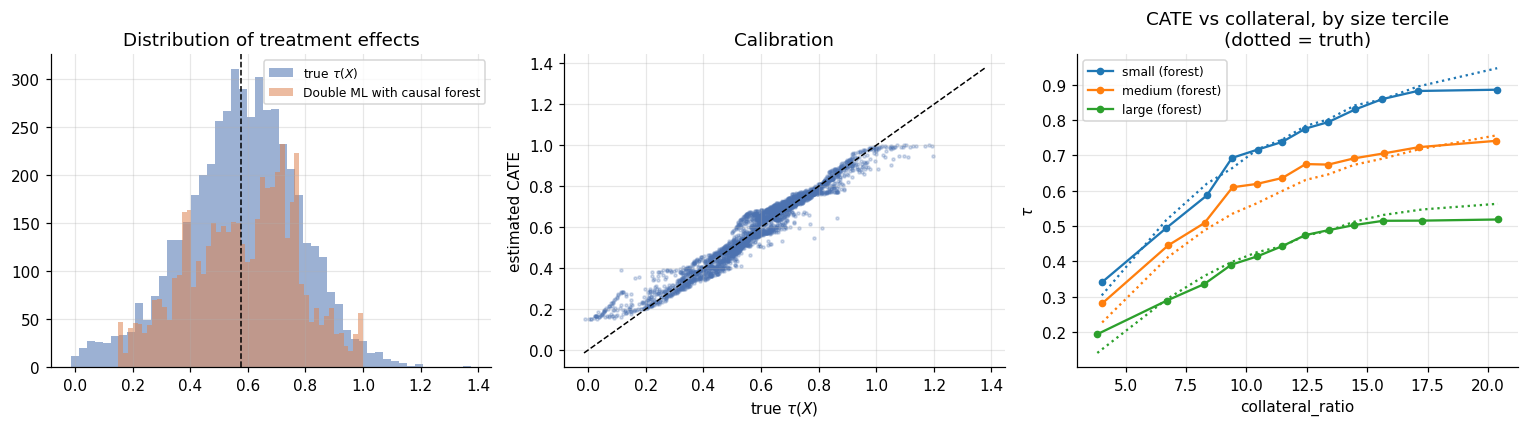

In [54]:
# Visualize the heterogeneity graphically
fig, ax = plt.subplots(1, 3, figsize=(14, 4))

ax[0].hist(df.tau_true, bins=50, alpha=.55, label="true $\\tau(X)$", color="#4C72B0")
ax[0].hist(cate,        bins=50, alpha=.55, label="Double ML with causal forest", color="#DD8452")
ax[0].axvline(TRUE_ATE, color="k", ls="--", lw=1)
ax[0].set_title("Distribution of treatment effects"); ax[0].legend(fontsize=8)

s = rng_global.choice(len(df), 3000, replace=False)
ax[1].scatter(df.tau_true.values[s], cate[s], s=4, alpha=.25, color="#4C72B0")
lim = [min(df.tau_true.min(), cate.min()), max(df.tau_true.max(), cate.max())]
ax[1].plot(lim, lim, "k--", lw=1)
ax[1].set_xlabel("true $\\tau(X)$"); ax[1].set_ylabel("estimated CATE")
ax[1].set_title("Calibration")

# THE figure: does the forest find the saturation?
tmp = df.assign(cbin=pd.qcut(df.collateral_ratio, 12, labels=False),
                sbin=pd.qcut(df.log_assets, 3, labels=["small", "medium", "large"]))
for lab, sub in tmp.groupby("sbin", observed=True):
    curve = sub.groupby("cbin").agg(x=("collateral_ratio", "mean"),
                                    est=("cate_hat", "mean"), true=("tau_true", "mean"))
    p = ax[2].plot(curve.x, curve.est, marker="o", ms=4, label=f"{lab} (forest)")
    ax[2].plot(curve.x, curve.true, ls=":", color=p[0].get_color())
ax[2].set_xlabel("collateral_ratio"); ax[2].set_ylabel(r"$\tau$")
ax[2].set_title("CATE vs collateral, by size tercile\n(dotted = truth)"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

## How the Causal Forests in the Last Step Split on Heterogeneity Drivers

,n,cate,ci_lo,ci_hi,truth
band,,,,,
Q1 collateral,1250,0.383,0.304,0.461,0.370
Q2,1250,0.592,0.522,0.662,0.573
Q3,1250,0.659,0.597,0.722,0.652
Q4 collateral,1250,0.698,0.627,0.770,0.716


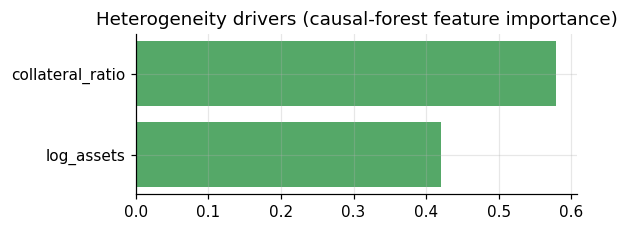

In [56]:
# group-level effects with intervals, and what the forest splits on
grp = (df.assign(lo=lo, hi=hi, band=pd.qcut(df.collateral_ratio, 4,
                 labels=["Q1 collateral", "Q2", "Q3", "Q4 collateral"]))
         .groupby("band", observed=True)
         .agg(n=("cate_hat", "size"), cate=("cate_hat", "mean"),
              ci_lo=("lo", "mean"), ci_hi=("hi", "mean"), truth=("tau_true", "mean"))
         .round(3))
display(grp)

imp = pd.Series(cf.feature_importances_, index=HET_X).sort_values()
fig, ax = plt.subplots(figsize=(5.5, 2.2))
ax.barh(imp.index, imp.values, color="#55A868")
ax.set_title("Heterogeneity drivers (causal-forest feature importance)")
plt.tight_layout(); plt.show()

## Summary in One, Simplified Surrogate Tree

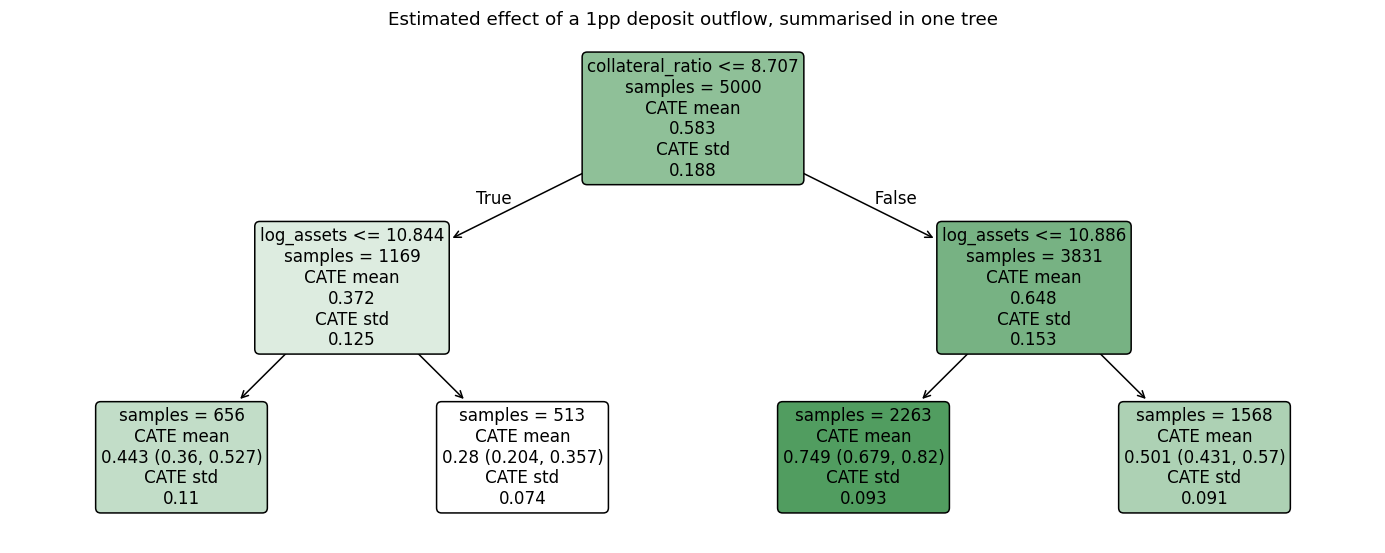

In [57]:
intrp = SingleTreeCateInterpreter(include_model_uncertainty=True, uncertainty_level=0.05,
                                  max_depth=2, min_samples_leaf=200, random_state=SEED)
intrp.interpret(cf, Xhet)

plt.figure(figsize=(16, 6))
intrp.plot(feature_names=HET_X, treatment_names=["+1pp deposit outflow"], fontsize=11)
plt.title("Estimated effect of a 1pp deposit outflow, summarised in one tree", fontsize=12)
plt.show()

# Day 1: Explainable Machine Learning

Now we use the toolset we learned to **explain the ML models**.

| Method | Library |
|---|---|
| PFI, PDP, ICE, ALE, H-statistic (unified) | `effector` `sklearn.inspection`|
| ALE | `PyALE` |
| SHAP | `shap` |
| SHAP of $\tau(X)$ | `econml` |

We will see that model **explanations answer a different question** than
the one answered before.

In [72]:
FEATURES = [D] + GOOD_W          # treatment + legitimate controls, no bad controls
X_tr, X_te, y_tr, y_te = train_test_split(df[FEATURES], df[Y], test_size=0.3, random_state=SEED)

# colsample_bynode: each split sees a random subset of features. With two near-identical
# columns this makes the model SPREAD credit between them rather than arbitrarily latching
# onto one - which is exactly what a real gradient-boosting pipeline does.
PARMS = dict(n_estimators=700, colsample_bynode=0.7)

model = xgb(3, **PARMS).fit(X_tr, y_tr)
print("features:", FEATURES)
print(f"out-of-sample R2 = {model.score(X_te, y_te):.4f}")
print("A very good predictive model. Now: what is it 'using'?")

features: ['deposit_outflow', 'cet1_ratio', 'collateral_ratio', 'log_assets', 'annual_report_pages']
out-of-sample R2 = 0.9435
A very good predictive model. Now: what is it 'using'?


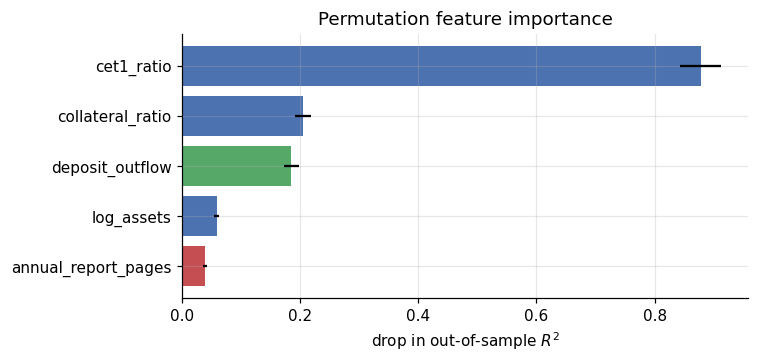

cet1_ratio             0.8780
collateral_ratio       0.2047
deposit_outflow        0.1848
log_assets             0.0587
annual_report_pages    0.0385
dtype: float64


In [71]:
# Permutation feature importance (sklearn.inspection)
pfi = permutation_importance(model, X_te, y_te, n_repeats=10,
                             random_state=SEED, scoring="r2", n_jobs=-1)
pfi_s  = pd.Series(pfi.importances_mean, index=FEATURES).sort_values()
pfi_sd = pd.Series(pfi.importances_std,  index=FEATURES)[pfi_s.index]

fig, ax = plt.subplots(figsize=(7, 3.4))
cols = ["#C44E52" if f == "annual_report_pages" else
        "#55A868" if f == D else "#4C72B0" for f in pfi_s.index]
ax.barh(pfi_s.index, pfi_s.values, xerr=1.96*pfi_sd.values, color=cols)
ax.set_xlabel("drop in out-of-sample $R^2$")
ax.set_title("Permutation feature importance")
plt.tight_layout(); plt.show()
print(pfi_s[::-1].round(4))

In [69]:
import effector

jD     = FEATURES.index(D)
d_bar  = df[D].mean()
d_grid = np.linspace(df[D].quantile(.02), df[D].quantile(.98), 40)

# the PREDICTIVE model, via effector
pdp_pred = effector.PDP(data=X_te.to_numpy(float), model=model.predict,
                        feature_names=FEATURES, target_name="cb_borrowing")
pdp_pred.plot(feature=jD, heterogeneity="ice", centering=True)

# pull the curve out so we can score it against the causal answer
try:
    pdp_curve = np.asarray(pdp_pred.eval(feature=jD, xs=d_grid, centering=True)).ravel()
except Exception as e:
    print(f"[pdp.eval unavailable: {type(e).__name__}] averaging directly")
    Xa = X_te.to_numpy(float)
    pdp_curve = np.array([model.predict(np.column_stack(
        [np.full(len(Xa), g) if k == jD else Xa[:, k] for k in range(Xa.shape[1])])).mean()
        for g in d_grid])
    pdp_curve -= pdp_curve.mean()

fig, ax = plt.subplots(figsize=(6.4, 4))
ax.plot(d_grid, TRUE_ATE*(d_grid - d_bar), "k--", lw=2, label=f"TRUTH (slope {TRUE_ATE:.2f})")
ax.plot(d_grid, ate*(d_grid - d_bar), lw=2.5, color="#55A868",
        label=f"LinearDML causal dose-response (slope {ate:.2f})")
ax.plot(d_grid, pdp_curve, lw=2, ls=":", color="#4C72B0", label="PDP of the predictive model")
ax.set_xlabel("deposit_outflow"); ax.set_ylabel("change in MLF recourse (% assets)")
ax.set_title("Two curves, two questions"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

TypeError: PDP.__init__() got an unexpected keyword argument 'feature_names'